In [82]:

# 데이터 로딩
import pandas as pd
df = pd.read_csv('../../data/csv/성적데이터.csv')

In [83]:
# 독립(정보), 종속(답) 분리
# hour : 학습시간
import numpy as np
X, y = np.array(df['hour']).reshape(-1, 1), np.where(df['score'] >= 60, 1, 0)


In [84]:
# 정규화 : 정보들의 값 범위가 제각각 => 같은 범위로 맞추는 것
# 학점 : 최대 4.5, 토익 최대 : 990
from tensorflow.keras import models, layers

nomalizer = layers.Normalization(axis=-1)
nomalizer.adapt(X)

In [85]:
# 모델 설계 : 은닉층, 출력층을 설계 
# 정규화를 모델 설계에 포함시킬 수 있음
model = models.Sequential([
	layers.Input((1,)),
	nomalizer, 
	layers.Dense(16, activation='relu'),
	layers.Dense(32, activation='relu'),
	layers.Dense(1, activation='sigmoid') # 출력층
])

In [86]:
# 모델 설정 : 옵티마이저, 손실함수 등을 설정(평가지표)
# 콜백함수(성능 최적화)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [87]:
# 학습
history = model.fit(X, y, verbose=0, epochs=100, shuffle=True, validation_split=0.2)

In [88]:
# 평가
eval = model.evaluate(X[16:], y[16:])

print(eval)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 1.0000 - loss: 0.1489
[0.14887940883636475, 1.0]


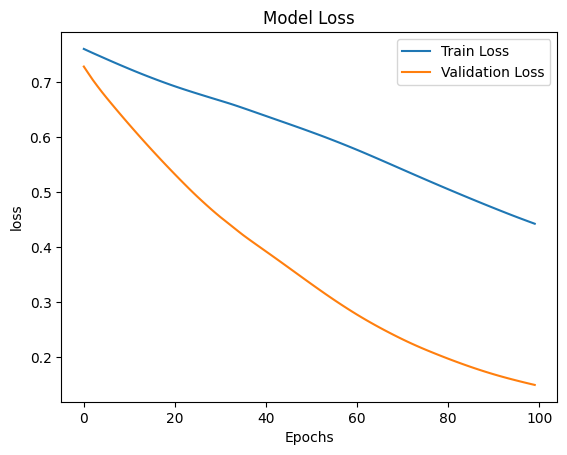

In [89]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

In [111]:
# 예측
학습시간들 = [[5.0],[10], [0]]
예측결과들 = model.predict(np.array(학습시간들))
for i in range(len(학습시간들)):
	학습시간 = 학습시간들[i][0]
	확률 = np.round(float(예측결과들[i][0] * 100.0) , 2)
	예측결과 = '합격' if 확률>=50 else '불합격'
	print(f'학습 시간 : {학습시간}, 예측 결과 : 합격확룔 {확률}% : {예측결과}')



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
학습 시간 : 5.0, 예측 결과 : 합격확룔 46.1% : 불합격
학습 시간 : 10, 예측 결과 : 합격확룔 93.07% : 합격
학습 시간 : 0, 예측 결과 : 합격확룔 17.57% : 불합격


In [105]:
print(np.round(1.234, 2))
type(1.23)

1.23


float